# Ethics in AI lab 5 - Measuring Fairness in Recommendation System using Metrics

## Name - Manan Chahal
## Roll No - 23102C0044

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Training the reccomendation System

In [2]:

df = pd.read_csv('data\\product_recommendation_dataset.csv')

df.head()

,age,gender,past_purchases,browsing_time,category,recommend
0,56,M,19,29,fashion,1
1,46,F,3,22,books,0
2,32,M,9,25,electronics,1
3,25,M,2,13,electronics,1
4,38,M,8,18,electronics,1


In [3]:
X = df.drop("recommend", axis=1)
y = df["recommend"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
categorical = ["gender","category"]
numerical = ["age","past_purchases","browsing_time"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(), categorical),
        ("num", "passthrough", numerical)
    ]
)

model = Pipeline([
    ("preprocessing", preprocessor),
    ("classifier", LogisticRegression())
])

In [5]:
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('cat', OneHotEncoder(),
                                                  ['gender', 'category']),
                                                 ('num', 'passthrough',
                                                  ['age', 'past_purchases',
                                                   'browsing_time'])])),
                ('classifier', LogisticRegression())])

In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.93


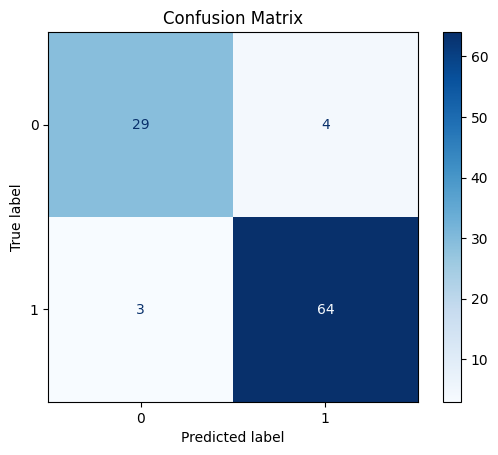

In [7]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# Fairness analysis
## 1) Disparate Impact

In [8]:
results = X_test.copy()
results["prediction"] = y_pred

male = results["gender"] == "M"
female = results["gender"] == "F"

p_male = results.loc[male, "prediction"].mean()
p_female = results.loc[female, "prediction"].mean()

disparate_impact = p_female / p_male

print("Disparate Impact:", disparate_impact)

Disparate Impact: 0.7426050856253243


### Since Disparate Impact is 0.7426050856253243 it violates the four fifths rule and is hence unfair

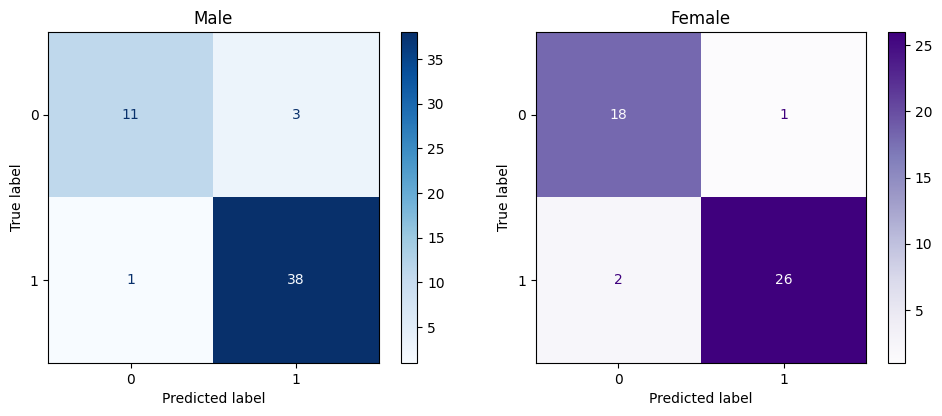

In [9]:
male_idx = results["gender"] == "M"
female_idx = results["gender"] == "F"

cm_male = confusion_matrix(y_test[male_idx], y_pred[male_idx])
cm_female = confusion_matrix(y_test[female_idx], y_pred[female_idx])

fig, ax = plt.subplots(1, 2, figsize=(10,4))

ConfusionMatrixDisplay(cm_male).plot(ax=ax[0], cmap="Blues")
ax[0].set_title("Male")

ConfusionMatrixDisplay(cm_female).plot(ax=ax[1], cmap="Purples")
ax[1].set_title("Female")

plt.tight_layout()
plt.show()

# 2) Equalised Odds

In [10]:
def compute_rates(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    tpr = tp / (tp + fn)
    fpr = fp / (fp + tn)
    
    return tpr, fpr

In [11]:

tpr_m, fpr_m = compute_rates(y_test[male_idx], y_pred[male_idx])
tpr_f, fpr_f = compute_rates(y_test[female_idx], y_pred[female_idx])

print("Male TPR:", tpr_m)
print("Female TPR:", tpr_f)

print("Male FPR:", fpr_m)
print("Female FPR:", fpr_f)

Male TPR: 0.9743589743589743
Female TPR: 0.9285714285714286
Male FPR: 0.21428571428571427
Female FPR: 0.05263157894736842


In [12]:
EOD = tpr_f - tpr_m
AAOD = (abs(fpr_f - fpr_m) + abs(tpr_f - tpr_m)) / 2

print("Equlised Odds Difference (EOD):", EOD)
print("Average Absolute Odds Difference (AAOD):", AAOD)

Equlised Odds Difference (EOD): -0.045787545787545736
Average Absolute Odds Difference (AAOD): 0.1037208405629458


The fairness evaluation indicates that the recommendation system exhibits measurable bias. The Disparate Impact value of 0.74 suggests that female users receive good recommendations at a lower rate than male users. Additionally, the Equal Opportunity Difference shows that the system is slightly less accurate in identifying relevant recommendations for female users. The AAOD value further confirms differences in prediction error rates between the groups. Overall, the system demonstrates moderate bias.